# Qwen 2.5 14B — Análisis Few-Shot v2

Análisis cuantitativo del CSV `qwen2.5_14b_fewshot_v2.csv` contra la validación humana (`validacion_real.csv`).

Cada celda renderiza una métrica o gráfico. No hay reporte `.md` adjunto: las celdas son la fuente de verdad.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (confusion_matrix, classification_report,
                              hamming_loss, jaccard_score, multilabel_confusion_matrix)
from collections import Counter

VERSION = 'v2'
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Carga de datos


In [2]:
LLM_DIR = Path.cwd().resolve().parent
INFERENCES_DIR = LLM_DIR / 'outputs' / 'inferences'
GT_DIR = LLM_DIR / 'outputs' / 'ground_truth'

df_llm = pd.read_csv(INFERENCES_DIR / f'qwen2.5_14b_fewshot_{VERSION}.csv')
df_human = pd.read_csv(GT_DIR / 'validacion_real.csv', sep=';', encoding='utf-8')
df_human.columns = df_human.columns.str.strip().str.lower()
df_human['doc_id'] = df_human['doc_id'].astype(str).str.strip()
df_llm['doc_id'] = df_llm['doc_id'].astype(str).str.strip()
print(f'LLM: {len(df_llm)} filas | Humano: {len(df_human)} filas')

LLM: 149 filas | Humano: 208 filas


## 2. Normalización de etiquetas humanas y LLM


In [3]:
HUMAN_COLS = ['1stpb', '2ndpb', '3rdpb']
PB_LABELS = ['None'] + [f'PB{i}' for i in range(1, 10)]

def parse_human_pbs(row):
    pbs = []
    for col in HUMAN_COLS:
        if col not in row.index:
            continue
        val = str(row[col]).strip()
        if val.lower() in ['nan', 'none', '']:
            continue
        if val.endswith('.0'):
            val = val[:-2]
        if val.isdigit():
            pbs.append(f'PB{val}')
        elif val.upper().startswith('PB'):
            pbs.append(val.upper())
    return pbs if pbs else ['None']

def parse_llm_pbs(prim, sec):
    pbs = []
    if isinstance(prim, str) and prim.strip() and prim.strip() not in ['None', 'Error']:
        pbs.append(prim.strip())
    if isinstance(sec, str) and sec.strip().lower() not in ['none', 'nan', '', 'error']:
        for s in sec.split(','):
            s = s.strip()
            if s and s not in pbs:
                pbs.append(s)
    return pbs if pbs else ['None']

df_human['human_pbs'] = df_human.apply(parse_human_pbs, axis=1)
df_human['human_primary'] = df_human['human_pbs'].apply(lambda x: x[0])

df_llm['llm_pbs'] = df_llm.apply(lambda r: parse_llm_pbs(r['llm_primary_pb'], r['llm_secondary_pbs']), axis=1)
df_llm['llm_primary'] = df_llm['llm_primary_pb'].fillna('None').replace('', 'None')

df = df_human[['doc_id', 'human_pbs', 'human_primary']].merge(
    df_llm[['doc_id', 'llm_pbs', 'llm_primary', 'llm_primary_conf']], on='doc_id', how='inner')
print(f'Cruzados: {len(df)} documentos')
df.head()

Cruzados: 150 documentos


,doc_id,human_pbs,human_primary,llm_pbs,llm_primary,llm_primary_conf
0,8581e74341ad,[None],None,[PB9],PB9,High
1,8d8ab7ed834f,"[PB1, PB4]",PB1,[PB1],PB1,High
2,ff6fb1e2be19,"[PB1, PB7]",PB1,[PB1],PB1,High
3,a3d6daa1a396,[None],None,[None],None,NaN
4,eaf6d52d5457,"[PB1, PB5]",PB1,[PB1],PB1,High


## 3. Métricas globales


In [4]:
def compute_metrics(df):
    exact_match = sum(set(r['human_pbs']) == set(r['llm_pbs']) for _, r in df.iterrows()) / len(df)
    top1 = (df['human_primary'] == df['llm_primary']).mean()

    none_human = df[df['human_primary'] == 'None']
    non_none_human = df[df['human_primary'] != 'None']
    hit_at_k = sum(r['human_primary'] in r['llm_pbs'] for _, r in non_none_human.iterrows()) / max(len(non_none_human), 1)
    true_neg = ((df['human_primary'] == 'None') & (df['llm_primary'] == 'None')).sum() / max(len(none_human), 1)
    rigorousness = true_neg
    pos_bias = ((df['human_primary'] == 'None') & (df['llm_primary'] != 'None')).sum() / max(len(none_human), 1)

    jaccards, hammings = [], []
    for _, r in df.iterrows():
        h, l = set(r['human_pbs']), set(r['llm_pbs'])
        jaccards.append(len(h & l) / max(len(h | l), 1))
        all_lbls = set(PB_LABELS[1:])
        hammings.append(len(h.symmetric_difference(l) & all_lbls) / 9)

    return {
        'Exact Match': exact_match, 'Top-1 Accuracy': top1, 'Hit@K': hit_at_k,
        'True Negative': true_neg, 'Rigorousness': rigorousness, 'Positivity Bias': pos_bias,
        'Jaccard avg': np.mean(jaccards), 'Hamming Loss': np.mean(hammings),
    }

metrics = compute_metrics(df)
metrics_df = pd.DataFrame([(k, f'{v:.3f}') for k, v in metrics.items()], columns=['Métrica', 'Valor'])
display(metrics_df)

,Métrica,Valor
0,Exact Match,0.507
1,Top-1 Accuracy,0.640
2,Hit@K,0.727
3,True Negative,0.529
4,Rigorousness,0.529
5,Positivity Bias,0.471
6,Jaccard avg,0.596
7,Hamming Loss,0.070


## 4. Reporte de clasificación (sklearn)


In [5]:
from sklearn.metrics import classification_report
labels_used = sorted(set(df['human_primary']) | set(df['llm_primary']))
labels_used = [l for l in PB_LABELS if l in labels_used]
report = classification_report(df['human_primary'], df['llm_primary'], labels=labels_used, zero_division=0)
print(report)

              precision    recall  f1-score   support

        None       0.69      0.53      0.60        51
         PB1       0.53      0.67      0.59        24
         PB2       0.64      0.88      0.74         8
         PB3       0.71      0.62      0.67         8
         PB4       0.67      0.60      0.63        10
         PB5       0.50      0.50      0.50         4
         PB6       0.50      0.50      0.50         4
         PB7       0.46      0.46      0.46        13
         PB8       0.67      0.86      0.75         7
         PB9       0.79      0.90      0.84        21

    accuracy                           0.64       150
   macro avg       0.62      0.65      0.63       150
weighted avg       0.65      0.64      0.64       150



## 5. Matriz de confusión normalizada


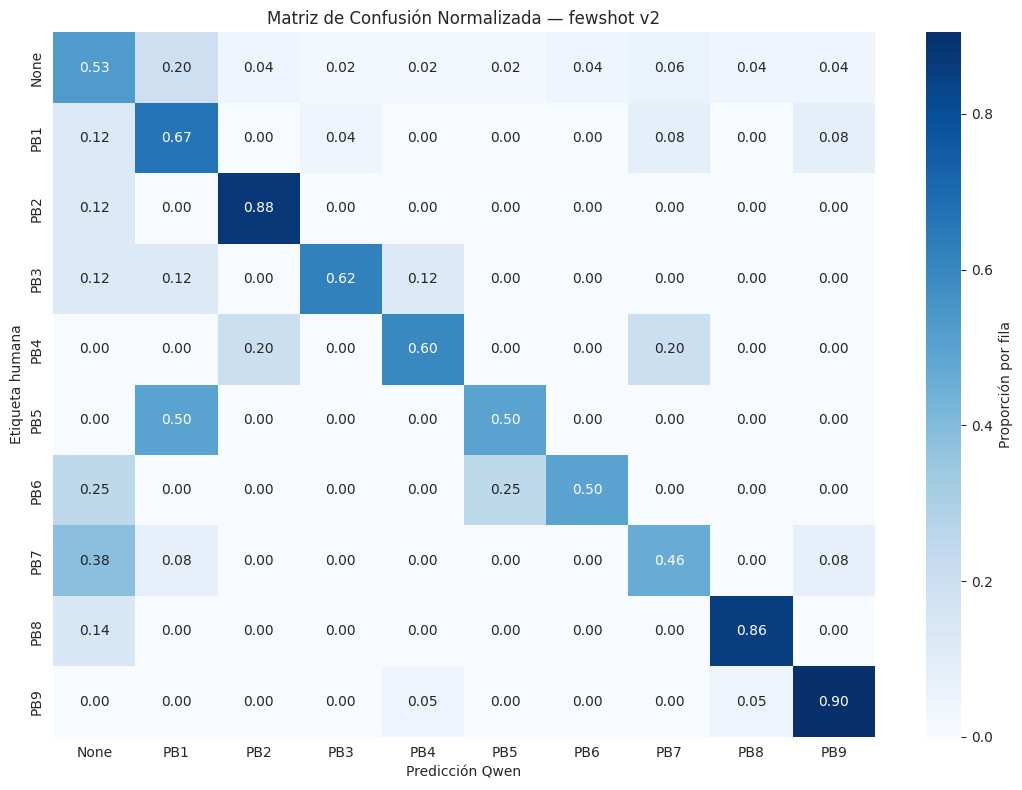

In [6]:
cm = confusion_matrix(df['human_primary'], df['llm_primary'], labels=labels_used)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_used, yticklabels=labels_used, ax=ax,
            cbar_kws={'label': 'Proporción por fila'})
ax.set_xlabel('Predicción Qwen'); ax.set_ylabel('Etiqueta humana')
ax.set_title(f'Matriz de Confusión Normalizada — fewshot {VERSION}')
plt.tight_layout(); plt.show()

## 6. Distribución de PBs asignados (overassignment)


Promedio humano: 0.87 | Promedio Qwen: 0.83


/tmp/ipykernel_1783990/1704718440.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Fuente', y='# PBs', ax=ax, palette=['#4C72B0', '#DD8452'])


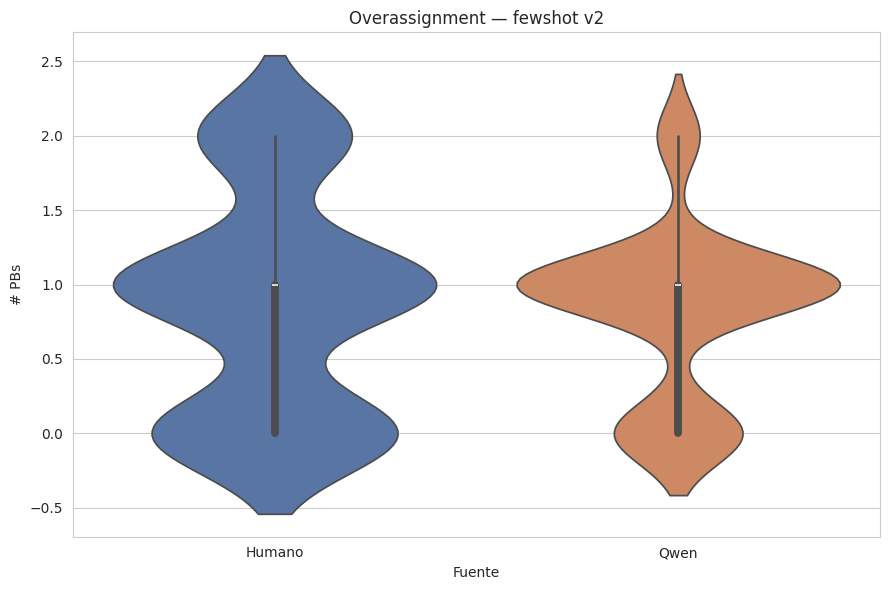

In [7]:
human_counts = df['human_pbs'].apply(lambda x: len([p for p in x if p != 'None']))
llm_counts = df['llm_pbs'].apply(lambda x: len([p for p in x if p != 'None']))

fig, ax = plt.subplots(figsize=(9, 6))
data = pd.DataFrame({'Humano': human_counts, 'Qwen': llm_counts}).melt(var_name='Fuente', value_name='# PBs')
sns.violinplot(data=data, x='Fuente', y='# PBs', ax=ax, palette=['#4C72B0', '#DD8452'])
ax.set_title(f'Overassignment — fewshot {VERSION}')
print(f'Promedio humano: {human_counts.mean():.2f} | Promedio Qwen: {llm_counts.mean():.2f}')
plt.tight_layout(); plt.show()

## 7. Accuracy por Planetary Boundary


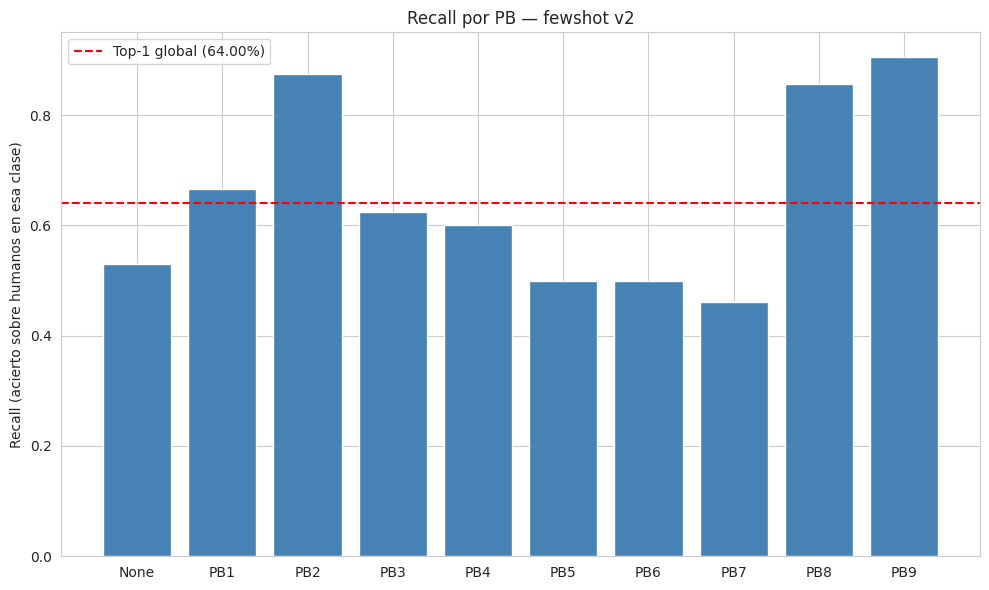

In [8]:
acc_por_pb = {}
for pb in labels_used:
    mask = df['human_primary'] == pb
    if mask.sum() > 0:
        acc_por_pb[pb] = (df.loc[mask, 'llm_primary'] == pb).mean()

fig, ax = plt.subplots(figsize=(10, 6))
pbs_sorted = list(acc_por_pb.keys())
ax.bar(pbs_sorted, [acc_por_pb[p] for p in pbs_sorted], color='steelblue')
ax.axhline(metrics['Top-1 Accuracy'], color='red', linestyle='--', label=f'Top-1 global ({metrics["Top-1 Accuracy"]:.2%})')
ax.set_ylabel('Recall (acierto sobre humanos en esa clase)')
ax.set_title(f'Recall por PB — fewshot {VERSION}')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Sesgo de positividad — qué inventa cuando humano dice None


Humano=None: 51 | LLM les puso un PB: 24


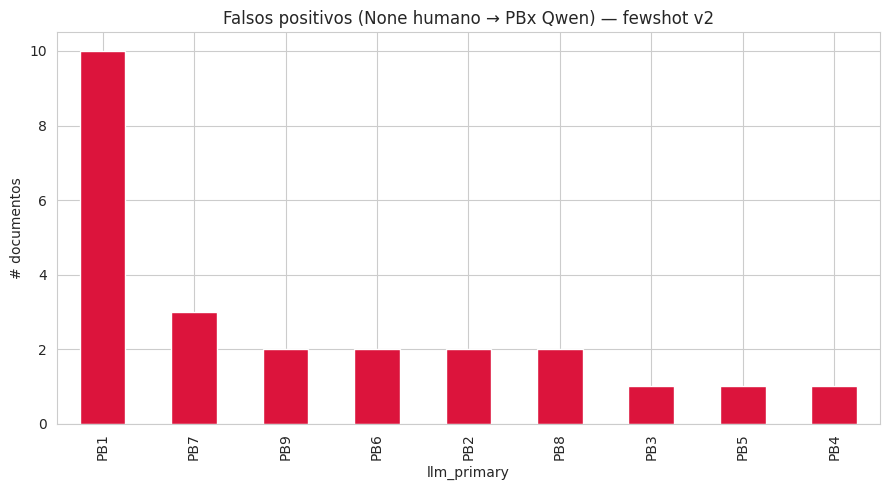

In [9]:
none_h = df[df['human_primary'] == 'None']
fp = none_h[none_h['llm_primary'] != 'None']['llm_primary'].value_counts()
print(f'Humano=None: {len(none_h)} | LLM les puso un PB: {len(none_h) - (none_h["llm_primary"] == "None").sum()}')
fig, ax = plt.subplots(figsize=(9, 5))
fp.plot(kind='bar', ax=ax, color='crimson')
ax.set_title(f'Falsos positivos (None humano → PBx Qwen) — fewshot {VERSION}')
ax.set_ylabel('# documentos'); plt.tight_layout(); plt.show()

## 9. Distribución de predicciones del LLM


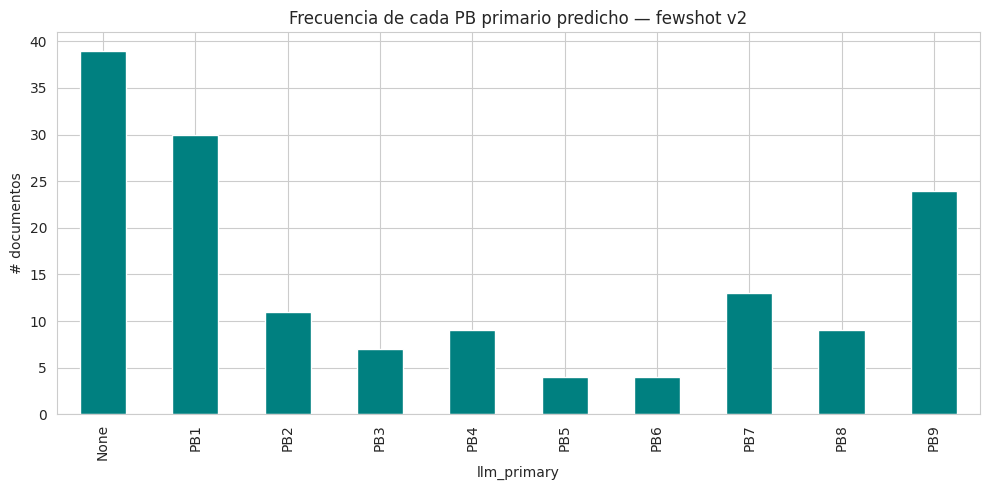

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
df['llm_primary'].value_counts().reindex(labels_used, fill_value=0).plot(kind='bar', ax=ax, color='teal')
ax.set_title(f'Frecuencia de cada PB primario predicho — fewshot {VERSION}')
ax.set_ylabel('# documentos'); plt.tight_layout(); plt.show()

## 10. Top confusiones (errores más frecuentes)


In [11]:
errors = df[df['human_primary'] != df['llm_primary']]
top_errs = errors.groupby(['human_primary', 'llm_primary']).size().reset_index(name='n').sort_values('n', ascending=False).head(15)
top_errs['confusión'] = top_errs['human_primary'] + ' → ' + top_errs['llm_primary']
display(top_errs[['confusión', 'n']])

,confusión,n
0,None → PB1,10
22,PB7 → None,5
9,PB1 → None,3
6,None → PB7,3
11,PB1 → PB7,2
8,None → PB9,2
7,None → PB8,2
5,None → PB6,2
19,PB5 → PB1,2
18,PB4 → PB7,2


## 11. Co-ocurrencia de PBs en las predicciones


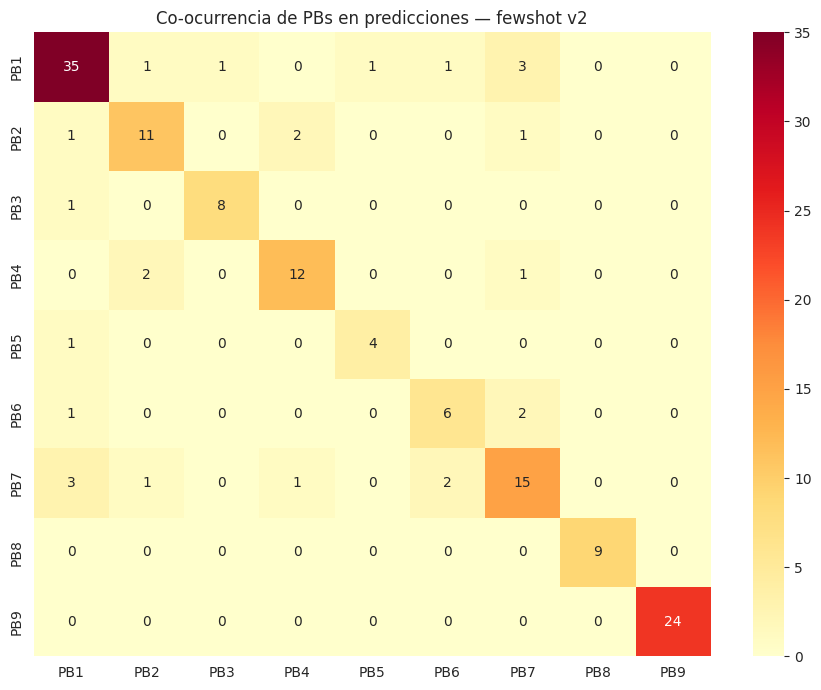

In [12]:
mat = np.zeros((len(PB_LABELS[1:]), len(PB_LABELS[1:])))
pbs_only = PB_LABELS[1:]
idx = {p: i for i, p in enumerate(pbs_only)}
for pbs in df['llm_pbs']:
    real = [p for p in pbs if p in idx]
    for a in real:
        for b in real:
            mat[idx[a]][idx[b]] += 1
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mat, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=pbs_only, yticklabels=pbs_only, ax=ax)
ax.set_title(f'Co-ocurrencia de PBs en predicciones — fewshot {VERSION}')
plt.tight_layout(); plt.show()

## 12. Matrices One-vs-Rest por PB


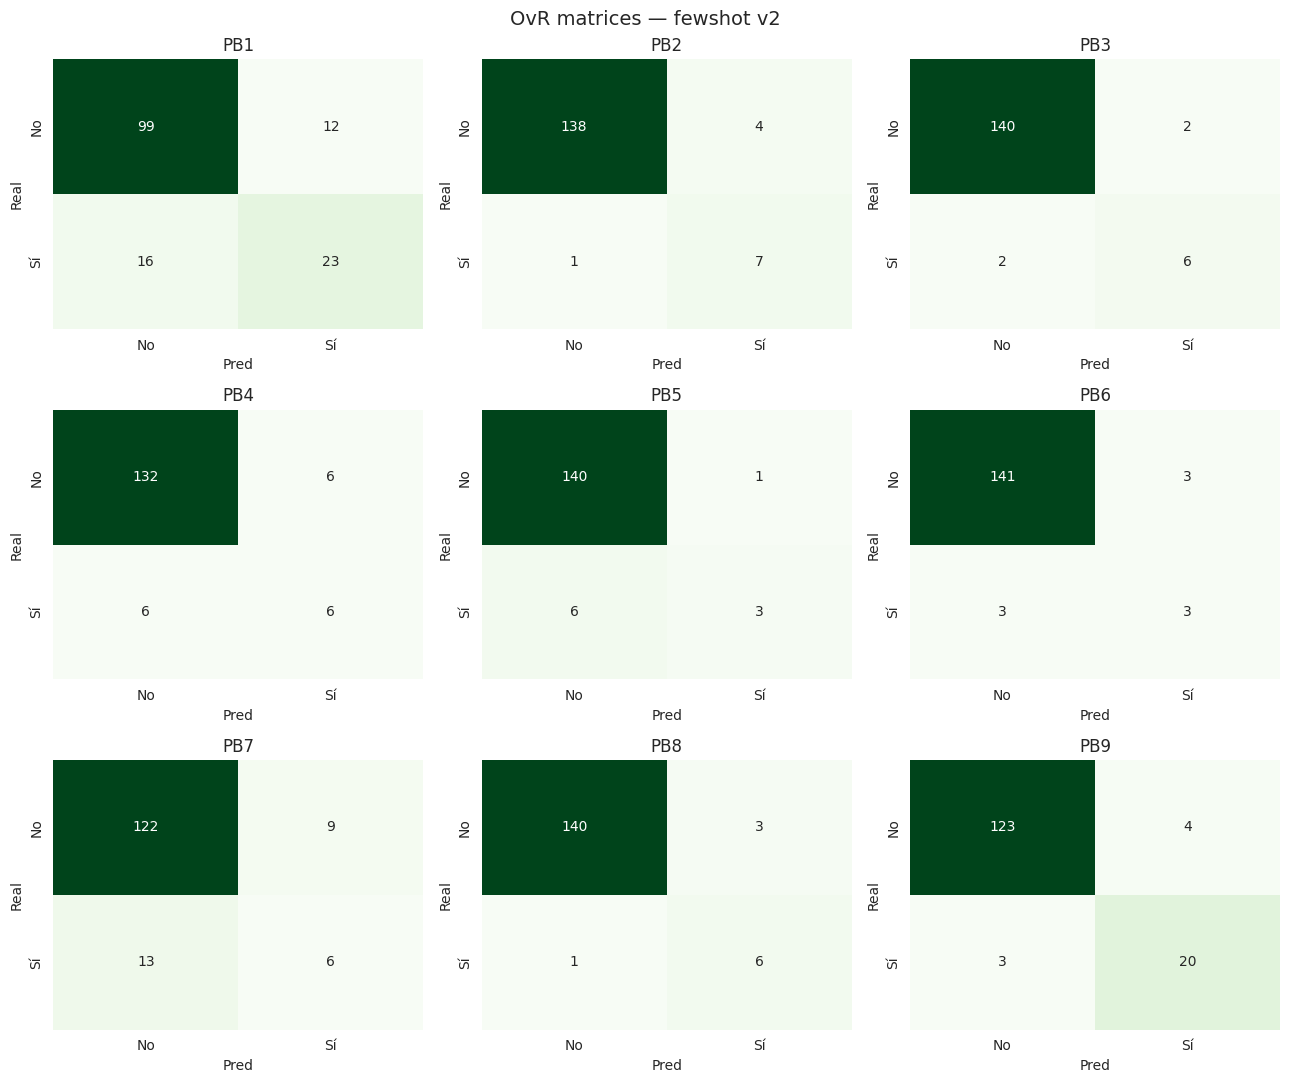

In [13]:
pbs_only = PB_LABELS[1:]
y_true_bin = np.array([[pb in row['human_pbs'] for pb in pbs_only] for _, row in df.iterrows()])
y_pred_bin = np.array([[pb in row['llm_pbs'] for pb in pbs_only] for _, row in df.iterrows()])

cm_ovr = multilabel_confusion_matrix(y_true_bin, y_pred_bin)
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for i, pb in enumerate(pbs_only):
    ax = axes[i // 3, i % 3]
    sns.heatmap(cm_ovr[i], annot=True, fmt='d', cmap='Greens',
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'], ax=ax, cbar=False)
    ax.set_title(pb); ax.set_xlabel('Pred'); ax.set_ylabel('Real')
plt.suptitle(f'OvR matrices — fewshot {VERSION}', fontsize=14)
plt.tight_layout(); plt.show()

## 13. Distribución de confianza del LLM


/tmp/ipykernel_1783990/2868351259.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='acierto', y='conf_num', ax=ax, palette=['#55A868', '#C44E52'])


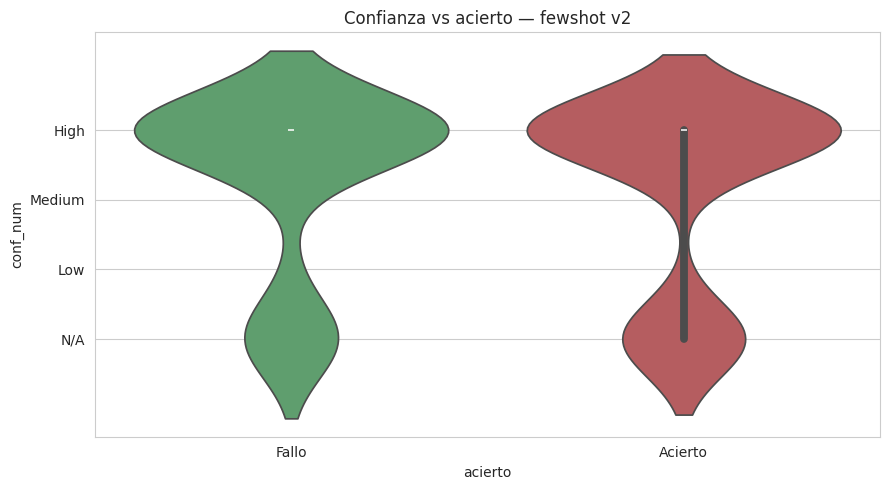

In [14]:
conf_map = {'High': 3, 'Medium': 2, 'Low': 1, 'N/A': 0, 'Unknown': 0, 'Error': 0}
df['conf_num'] = df['llm_primary_conf'].fillna('N/A').map(conf_map).fillna(0)
df['acierto'] = (df['human_primary'] == df['llm_primary']).map({True: 'Acierto', False: 'Fallo'})

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df, x='acierto', y='conf_num', ax=ax, palette=['#55A868', '#C44E52'])
ax.set_yticks([0, 1, 2, 3]); ax.set_yticklabels(['N/A', 'Low', 'Medium', 'High'])
ax.set_title(f'Confianza vs acierto — fewshot {VERSION}')
plt.tight_layout(); plt.show()

## 14. Tiempo de inferencia


count    149.000000
mean       4.001517
std        1.383284
min        2.157385
25%        2.810340
50%        3.949426
75%        4.863942
max       11.557173
Name: inference_time_sec, dtype: float64


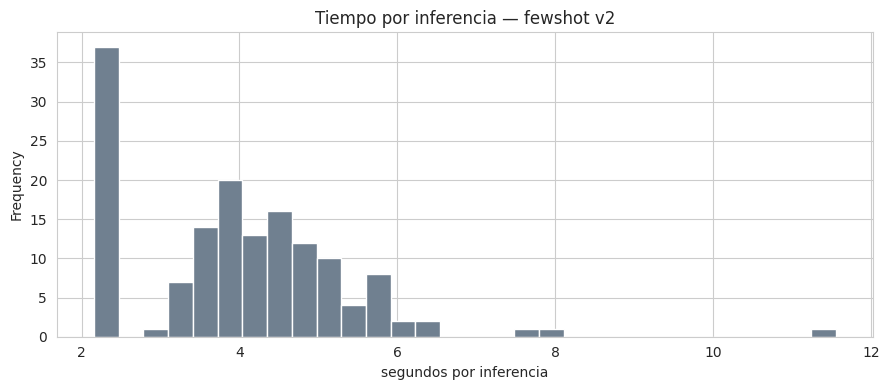

In [15]:
print(df_llm['inference_time_sec'].describe())
fig, ax = plt.subplots(figsize=(9, 4))
df_llm['inference_time_sec'].plot(kind='hist', bins=30, ax=ax, color='slategray')
ax.set_xlabel('segundos por inferencia'); ax.set_title(f'Tiempo por inferencia — fewshot {VERSION}')
plt.tight_layout(); plt.show()